# Нейросимвольная интерпретация ионограмм: полное исследование

Объединяет и развивает `prototype2.ipynb` (вертикальное зондирование) и `oblique.ipynb`
(синтетическое наклонное). Три вопроса исследования:

> **Q1. Можно ли получить качественную синтетику для обучения?** — аналитический мост ВЗ→НЗ
> (сферическая геометрия) + нейрорендерер шума; валидация против ARTIST M3000F2, против
> точной трассировки по профилю, и цикл-тест интерпретируемости.
>
> **Q2. Как работает тензорная логика (релаксация)?** — заземление → атомы → t-нормы;
> hinge против softplus; правило детача опорной стороны; эффект на реальных и синтетических
> данных.
>
> **Q3. Как работают SHACL-гейты и что они дают?** — жёсткий контур поверх мягкого:
> браковка предсказаний, диагностика учителя и синтетики, гейт как фильтр качества.

Методика и литература: `data/oblique_synthesis.md`, `data/format_description.md` §I.8;
онтология: `03-ionograms-ontology/research/onto/` (README там же). Прогон целиком —
Apple GPU (MPS), ~45 мин.

In [1]:
import sys, glob, time, warnings
warnings.filterwarnings("ignore")
ROOT = "/Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms"
sys.path.insert(0, ROOT); sys.path.insert(0, f"{ROOT}/03-ionograms-ontology/research/onto")
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from modules import digi_formats as dfm
from modules import oblique_synth as obs
import validate as vd
from rdflib import Graph, Namespace, RDF, Literal
from rdflib.namespace import XSD
IONO = Namespace("http://scilibai.ru/onto/iono#")
torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"font.size": 9, "figure.dpi": 100})
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
vocab = vd.load_vocabulary()
print("device:", DEV, "| онтология:", len(vocab), "триплетов")

device: mps | онтология: 1704 триплетов


## 1. Данные и постановка

**Вход** $x\in[0,1]^{2\times128\times128}$ — амплитуда над шумом (порог: медиана + 6 дБ) для
O/X-каналов, решётка 1–15 МГц × 80–720 км. **Цель** — маска классов следов
$\{BG,F2,F1,E,Es\}$ из SAO-полилиний ARTIST. Учитель **слабый** (ARTIST ошибается в
20–40 % сложных случаев — Галкин; NOIRE-Net и Castro et al. подтверждают на своих сетях),
поэтому постановка: обучение с ограничением $\Phi(x)\models\mathcal{O}$ — онтология
участвует (а) релаксацией в лоссе, (б) SHACL-гейтом на инференсе, (в) фильтром данных.
Корпус: NOAA (MO155-2019, JR055/PQ052/JI91J-2022 + RO041), сплит хронологический.

In [2]:
CACHE = f"{ROOT}/data/corpus_cache"
meta = pd.read_csv(f"{CACHE}/meta.csv").sort_values(["shard", "idx"]).reset_index(drop=True)
X_u8 = np.concatenate([np.load(s)["X"] for s in sorted(glob.glob(f"{CACHE}/shard_*.npz"))])
Y_all = np.concatenate([np.load(s)["Y"] for s in sorted(glob.glob(f"{CACHE}/shard_*.npz"))])  # int8!
meta["time"] = pd.to_datetime(meta["time"])
val_mask = np.zeros(len(meta), bool)
for st, idx in meta.groupby("station").groups.items():
    order = meta.loc[idx].sort_values("time").index.to_numpy()
    val_mask[order[int(len(order) * 0.75):]] = True
tr_i, va_i = np.where(~val_mask)[0], np.where(val_mask)[0]
CLASSES = ["BG", "F2", "F1", "E", "Es"]
cm_y = ListedColormap(["black", "cyan", "lime", "yellow", "magenta"])
f_axis = np.linspace(1, 15, 128); h_axis = np.linspace(80, 720, 128)
print(f"{len(X_u8)} ионограмм ({X_u8.nbytes/2**30:.1f} ГБ), train {len(tr_i)} / val {len(va_i)}")
print(meta.station.value_counts().to_dict())

29166 ионограмм (0.9 ГБ), train 21872 / val 7294
{'PQ052': 13689, 'MO155': 7593, 'JR055': 6728, 'JI91J': 1067, 'RO041': 89}


## 2. Онтология и SHACL — фундамент Q3

Ключ: **след ≠ мода**. След (`IonogramTrace`) — кривая на картинке (информационный объект);
мода (`PropagationMode`) — физический процесс; интерпретация — ребро `denotes`. Мода и
характеристика — **кортежи признаков** (кратность × слой × луч × O/X), именованные классы
(`Mode_1F2`, `Char_foF2`) выводит ризонер. Онтология (ядро 0.3.0, 5 модулей, ~1700 триплетов,
107 классов) прошла 5 независимых ревью; формы: гигиена H0–H5, НЗ S1–S6, ВЗ V3–V4
(кратник $h'_n = n h'_1$; O/X: $f_o^2 = f_x(f_x - f_B)$), характеристики Q1–Q10.
Проверка ТОЛЬКО через `validate.py`: гигиена → owlrl-замыкание → pyshacl
(один numpy-литерал молча отравляет SPARQL-сравнения — потому три стадии).

In [3]:
# аксиома как есть + вывод ризонером + гейт на трёх сценах
print(vocab.cbd(IONO.Mode_1F2).serialize(format="turtle").replace("http://scilibai.ru/onto/iono#", "iono:"))
import owlrl
g = Graph(); m = IONO.demo
for t in [(m, RDF.type, IONO.PropagationMode), (m, IONO.hasHopCount, Literal(2, datatype=XSD.integer)),
          (m, IONO.hasRayType, IONO.lowerRay), (m, IONO.hasMagnetoionicComponent, IONO.ordinary),
          (m, IONO.reflectsFromLayer, IONO.Layer_F2)]: g.add(t)
gg = g + vocab; owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(gg)
print("написали ПРИЗНАКИ -> ризонер вывел:",
      [str(o).split('#')[-1] for o in gg.objects(m, RDF.type) if "Mode_" in str(o)])

def vs_scene(name, modes, gyro=1.3):
    g = Graph(); ion = IONO["ion_" + name]
    g.add((ion, RDF.type, IONO.VerticalIonogram)); g.add((ion, IONO.hasGyroFrequency, vd.dec(gyro)))
    for i, (hop, layer, comp, mof, hkm) in enumerate(modes, 1):
        tr, mo = IONO[f"{name}_t{i}"], IONO[f"{name}_m{i}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode),
                  (mo, IONO.hasHopCount, Literal(int(hop), datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay), (mo, IONO.hasMagnetoionicComponent, IONO[comp]),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]),
                  (mo, IONO.hasMOFValue, vd.dec(mof)),
                  (mo, IONO.hasMinDelayValue, vd.dec(2 * hkm / 299.792458))]: g.add(t)
    return g
good = [(1, "F2", "ordinary", 8.2, 223), (1, "F2", "extraordinary", 8.86, 228), (2, "F2", "ordinary", 8.2, 446)]
print("\n>>> корректная сцена:"); vd.validate_scene(vs_scene("ok", good), vocab)
print(">>> кратник перепутан:")
vd.validate_scene(vs_scene("swap", [(1, "F2", "ordinary", 8.2, 446), (2, "F2", "ordinary", 8.2, 223)]), vocab)
print(">>> numpy-литерал (гигиена до замыкания):")
g = vs_scene("dirty", good[:1]); g.remove((IONO.dirty_m1, IONO.hasMOFValue, None))
g.add((IONO.dirty_m1, IONO.hasMOFValue, Literal(np.float64(8.25), datatype=XSD.decimal)))
_ = vd.validate_scene(g, vocab)

@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<iono:Mode_1F2> a owl:Class ;
    rdfs:label "Мода 1F2"@ru ;
    owl:equivalentClass [ a owl:Class ;
            owl:intersectionOf ( <iono:PropagationMode> [ a owl:Restriction ;
                        owl:hasValue 1 ;
                        owl:onProperty <iono:hasHopCount> ] [ a owl:Restriction ;
                        owl:onProperty <iono:reflectsFromLayer> ;
                        owl:someValuesFrom <iono:LayerF2> ] [ a owl:Restriction ;
                        owl:hasValue <iono:lowerRay> ;
                        owl:onProperty <iono:hasRayType> ] ) ] .




написали ПРИЗНАКИ -> ризонер вывел: ['Mode_2F2']

>>> корректная сцена:


  допустима: True | нарушений 0, предупреждений 0
>>> кратник перепутан:


  допустима: False | нарушений 2, предупреждений 0
    ✗ S2: нарушена монотонность задержки по кратности — задержка моды http://scilibai.ru/onto/iono#swap_m2 меньше за
    ✗ V3: задержка кратника http://scilibai.ru/onto/iono#swap_m2 не кратна задержке основного следа http://scilibai.
>>> numpy-литерал (гигиена до замыкания):
  ГИГИЕНА НЕ ПРОЙДЕНА — замыкание и содержательные формы не запускались:
    H✗ Value is not Literal with datatype xsd:decimal


## 3. Тензорная логика — теория Q2

**Слой 1. Заземление.** Из логитов $z$: $p=\mathrm{softmax}_C(z)$, и для класса $c$ в столбце $f$:
масса $m_c(f)=\sum_h p_c(h,f)$; присутствие $\pi_c(f)=\mathrm{clip}(m_c(f)/m_0,0,1)$;
soft-argmax высоты $\hat h_c(f)=\sum_h h\,p_c(h,f)/(m_c(f)+\varepsilon)$; всё дифференцируемо.

**Слой 2. Атомы.** Неравенство $a<b$ → штраф за нарушение $v=(a-b+\text{margin})/\tau$.

**Слой 3. Связки.** Конъюнкция — сумма штрафов (product t-norm ⇔ сумма $-\log$ истинностей),
квантор — взвешенное среднее по столбцам/образцам. Итог: $L = L_{CE} + \lambda L_{logic}$.

**Две релаксации** $\mathrm{penalty}(v)$:
$$\text{hinge}(v)=\max(0,v)\qquad \text{softplus}_\beta(v)=\tfrac1\beta\log(1+e^{\beta v})=-\tfrac1\beta\log\sigma(-\beta v)$$
hinge — аналог мягких зазоров SVM (нулевая цена в допуске); softplus — гладкий $-\log$
истинности сигмоидного атома, тянет решения вглубь допустимой области.

**Правило детача (выучено на опыте, см. §8).** У каждого ограничения должно быть явно
назначено, *кого оно имеет право двигать*: (а) гейты присутствия $\pi$ детачатся — иначе сеть
«выключает» классы вместо исправления геометрии; (б) **опорная сторона неравенства детачится**
— иначе softplus-градиент в выполненном состоянии раздувает эталон (сеть подмешивала фантомные
пиксели F2 на высоких частотах, «углубляя» выполнение S1 и ломая ридаут МПЧ: RMSE 1.9→3.9 МГц).

Пропозиции ВЗ (источники — формы онтологии): **P1** порядок высот слоёв ($\bar h_E+20<\bar h_{F2}$ …,
форма S4); **P2** связность следа ($|\Delta\hat h|\le60$ км, РД §7.3.7); **P3** «не кратник»
($\hat h_{F2}(f)\le1.8\min\hat h_{F2}$, форма V3); **P4** порядок частот слоёв
($f_{max}^{E}<f_{max}^{F1}<f_{max}^{F2}$, форма Q1; Es исключён — предельная частота).
Полная сверка «какие формы онтологии покрыты релаксацией, какие только гейтом и почему» — §4.2.

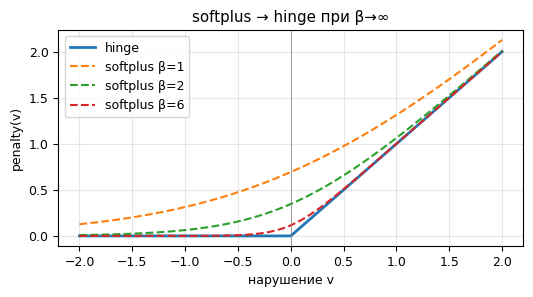

необученная сеть: L_hinge = 0.317


In [4]:
v = torch.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(v, torch.relu(v), lw=2, label="hinge")
for b in [1, 2, 6]: ax.plot(v, Fn.softplus(v, beta=b), "--", label=f"softplus β={b}")
ax.axvline(0, color="gray", lw=.5); ax.legend(); ax.grid(alpha=.3)
ax.set(xlabel="нарушение v", ylabel="penalty(v)", title="softplus → hinge при β→∞")
plt.show()

h_t = torch.tensor(h_axis, dtype=torch.float32); MASS0 = 3.0
iF2, iF1, iE, iEs = 0, 1, 2, 3

def readouts(logits):
    p = logits.softmax(1)
    mass = p[:, 1:].sum(2)
    pres = (mass / MASS0).clamp(0, 1)
    h_soft = (p[:, 1:] * h_t.to(logits.device).view(1,1,-1,1)).sum(2) / (mass + 1e-6)
    w = pres / (pres.sum(-1, keepdim=True) + 1e-6)
    return pres, h_soft, (h_soft * w).sum(-1), pres.mean(-1)

def logic_loss(logits, variant="hinge"):
    pres, h_soft, h_mean, present = readouts(logits)
    pen = (lambda u: Fn.relu(u)) if variant == "hinge" else (lambda u: Fn.softplus(u, beta=2.0))
    g = lambda a, b: (present[:, a] * present[:, b]).detach()          # детач гейтов
    P1 = g(iE, iF2)  * pen((h_mean[:, iE]  - h_mean[:, iF2] + 20) / 100) \
       + g(iF1, iF2) * pen((h_mean[:, iF1] - h_mean[:, iF2] + 10) / 100) \
       + g(iE, iF1)  * pen((h_mean[:, iE]  - h_mean[:, iF1] + 10) / 100)
    dh = (h_soft[:, :, 1:] - h_soft[:, :, :-1]).abs()
    wc = (pres[:, :, 1:] * pres[:, :, :-1]).detach()
    P2 = (wc * pen((dh - 60) / 100)).sum((1, 2)) / (wc.sum((1, 2)) + 1e-6)
    hmin = h_soft[:, iF2].min(-1).values
    P3 = (pres[:, iF2].detach() * pen((h_soft[:, iF2] - 1.8 * hmin.unsqueeze(-1)) / 100)).mean(-1)
    # P4 (НОВОЕ, релаксация формы Q1): порядок предельных частот слоёв foE < foF1 < foF2.
    # fmax — logsumexp-заземление максимальной частоты присутствия класса; опора детачится
    # (подавляем класс-нарушитель, не раздуваем верхний). Es ИСКЛЮЧЁН — как и в самой Q1:
    # foEs — предельная, не критическая частота, ночью законно превышает foF2 (ревью Ф-01).
    fn = torch.linspace(0, 1, pres.shape[-1], device=logits.device)
    fmax = torch.logsumexp(torch.log(pres + 1e-6) + 12 * fn, -1) / 12
    P4 = g(iE, iF2)  * pen(fmax[:, iE]  - fmax[:, iF2].detach() + 0.01)        + g(iE, iF1)  * pen(fmax[:, iE]  - fmax[:, iF1].detach() + 0.01)        + g(iF1, iF2) * pen(fmax[:, iF1] - fmax[:, iF2].detach() + 0.01)
    return (P1 + P2 + P3 + P4).mean()

class Block(nn.Module):
    def __init__(s, ci, co):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU())
    def forward(s, x): return s.n(x)

class UNet(nn.Module):
    def __init__(s, cin, cout, base=16, coords=False):
        super().__init__(); s.coords = coords
        cin += 2 if coords else 0
        s.d1, s.d2, s.d3 = Block(cin, base), Block(base, base*2), Block(base*2, base*4)
        s.u2 = nn.ConvTranspose2d(base*4, base*2, 2, 2); s.b2 = Block(base*4, base*2)
        s.u1 = nn.ConvTranspose2d(base*2, base, 2, 2);   s.b1 = Block(base*2, base)
        s.head = nn.Conv2d(base, cout, 1); s.pool = nn.MaxPool2d(2)
    def forward(s, x):
        if s.coords:
            B, _, H, W = x.shape
            hh = torch.linspace(0, 1, H, device=x.device).view(1,1,H,1).expand(B,1,H,W)
            ww = torch.linspace(0, 1, W, device=x.device).view(1,1,1,W).expand(B,1,H,W)
            x = torch.cat([x, hh, ww], 1)
        c1 = s.d1(x); c2 = s.d2(s.pool(c1)); c3 = s.d3(s.pool(c2))
        y = s.b2(torch.cat([s.u2(c3), c2], 1)); y = s.b1(torch.cat([s.u1(y), c1], 1))
        return s.head(y)

lg = UNet(2, 5)(torch.tensor(X_u8[va_i[:8]], dtype=torch.float32).div_(255))
print("необученная сеть: L_hinge =", round(float(logic_loss(lg)), 3))

## 4. Эксперимент 1: вертикальное зондирование (реальные данные, слабый учитель)

4 рана × 6 эпох на 21.9 тыс. train-ионограмм: `baseline` / `+hinge` / `+lognorm` /
`+coords` (абляция координатных каналов). Одинаковые сиды и порядок батчей.

baseline


  [baseline] ep0: val_CE 0.118  val_L_hinge 0.0518


  [baseline] ep1: val_CE 0.103  val_L_hinge 0.0499


  [baseline] ep2: val_CE 0.106  val_L_hinge 0.0715


  [baseline] ep3: val_CE 0.094  val_L_hinge 0.0863


...

  [+coords] ep1: val_CE 0.099  val_L_hinge 0.0509


  [+coords] ep2: val_CE 0.101  val_L_hinge 0.0623


  [+coords] ep3: val_CE 0.091  val_L_hinge 0.0511


  [+coords] ep4: val_CE 0.089  val_L_hinge 0.0551


  [+coords] ep5: val_CE 0.087  val_L_hinge 0.0610
обучение ВЗ: 1278 с


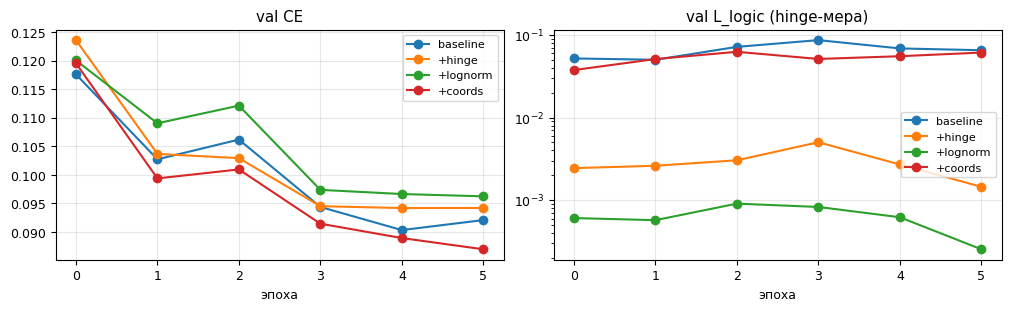

In [5]:
BS = 64
ce_w = torch.tensor([0.05, 1, 1, 1, 1.], device=DEV)

def batches(idx, bs, shuffle=True):
    order = np.random.permutation(idx) if shuffle else idx
    for k in range(0, len(order), bs):
        j = order[k:k+bs]
        yield (torch.tensor(X_u8[j], dtype=torch.float32, device=DEV).div_(255),
               torch.tensor(Y_all[j], device=DEV).long())

def train_run(name, coords=False, logic=None, lam=0.5, epochs=6, lr=2e-3):
    torch.manual_seed(0); np.random.seed(0)
    net = UNet(2, 5, coords=coords).to(DEV)
    opt = torch.optim.Adam(net.parameters(), lr)
    ce = nn.CrossEntropyLoss(weight=ce_w); hist = []
    for ep in range(epochs):
        net.train()
        for x, y in batches(tr_i, BS):
            opt.zero_grad(); lg = net(x); loss = ce(lg, y)
            if logic: loss = loss + lam * logic_loss(lg, logic)
            loss.backward(); opt.step()
        net.eval(); vl = vll = vn = 0
        with torch.no_grad():
            for x, y in batches(va_i[:4096], 128, shuffle=False):
                lg = net(x); vl += ce(lg, y).item()*len(x); vll += float(logic_loss(lg))*len(x); vn += len(x)
        hist.append(dict(ep=ep, val_ce=vl/vn, val_logic=vll/vn))
        print(f"  [{name}] ep{ep}: val_CE {vl/vn:.3f}  val_L_hinge {vll/vn:.4f}")
    return net.cpu(), pd.DataFrame(hist)

t0 = time.time(); runs = {}
for name, kw in [("baseline", {}), ("+hinge", dict(logic="hinge")),
                 ("+lognorm", dict(logic="lognorm")), ("+coords", dict(coords=True))]:
    print(name); runs[name] = train_run(name, **kw)
print(f"обучение ВЗ: {time.time()-t0:.0f} с")
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
for name, (net, h) in runs.items():
    axes[0].plot(h.ep, h.val_ce, "o-", label=name); axes[1].plot(h.ep, h.val_logic, "o-", label=name)
axes[0].set_title("val CE"); axes[1].set_title("val L_logic (hinge-мера)"); axes[1].set_yscale("log")
for ax in axes: ax.set_xlabel("эпоха"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

In [6]:
def predict(net, idx, bs=128, ncls=5):
    net = net.to(DEV).eval(); out = []
    with torch.no_grad():
        for k in range(0, len(idx), bs):
            x = torch.tensor(X_u8[idx[k:k+bs]], dtype=torch.float32, device=DEV).div_(255)
            out.append(net(x).argmax(1).cpu().numpy())
    net.cpu(); return np.concatenate(out)

def fo_readout(pm, ci=1):
    cols = np.where((pm == ci).sum(0) >= 2)[0]
    return f_axis[cols[-1]] if len(cols) else np.nan

def hmin_readout(pm, ci=1):
    rows = np.where((pm == ci).any(1))[0]
    return h_axis[int(np.percentile(rows, 5))] if len(rows) else np.nan

VA = va_i[:4096]; yv = Y_all[VA]
preds = {name: predict(net, VA) for name, (net, h) in runs.items()}
rows = []
for name, pm in preds.items():
    r = dict(run=name)
    for ci, cls in enumerate(CLASSES[1:], 1):
        inter = ((pm == ci) & (yv == ci)).sum(); union = ((pm == ci) | (yv == ci)).sum()
        r[f"IoU_{cls}"] = round(inter/union, 3)
    fo_p = np.array([fo_readout(pm[k]) for k in range(len(VA))]); fo_t = meta.foF2.values[VA]
    ok = np.isfinite(fo_p) & np.isfinite(fo_t)
    r["foF2_RMSE"] = round(float(np.sqrt(np.mean((fo_p[ok]-fo_t[ok])**2))), 2)
    rows.append(r)
display(pd.DataFrame(rows).set_index("run"))

,IoU_F2,IoU_F1,IoU_E,IoU_Es,foF2_RMSE
run,,,,,
baseline,0.313,0.227,0.473,0.381,0.29
+hinge,0.309,0.194,0.467,0.388,0.26
+lognorm,0.334,0.199,0.451,0.371,0.24
+coords,0.285,0.214,0.449,0.373,0.27


### 4.0a. Иллюстрация: как сеть «читает» пропозиции (заземление вживую)

Берём валидационную ионограмму, на которой baseline и +lognorm разошлись сильнее всего по
классу F2, и показываем сами заземлённые величины: присутствие $\pi_{F2}(f)$, soft-высоту
$\hat h_{F2}(f)$ с порогом кратника $1.8\min\hat h_{F2}$ (пропозиция P3/V3) и постолбцовый
вклад штрафа P3. Видно буквально, за что и где логика штрафует.

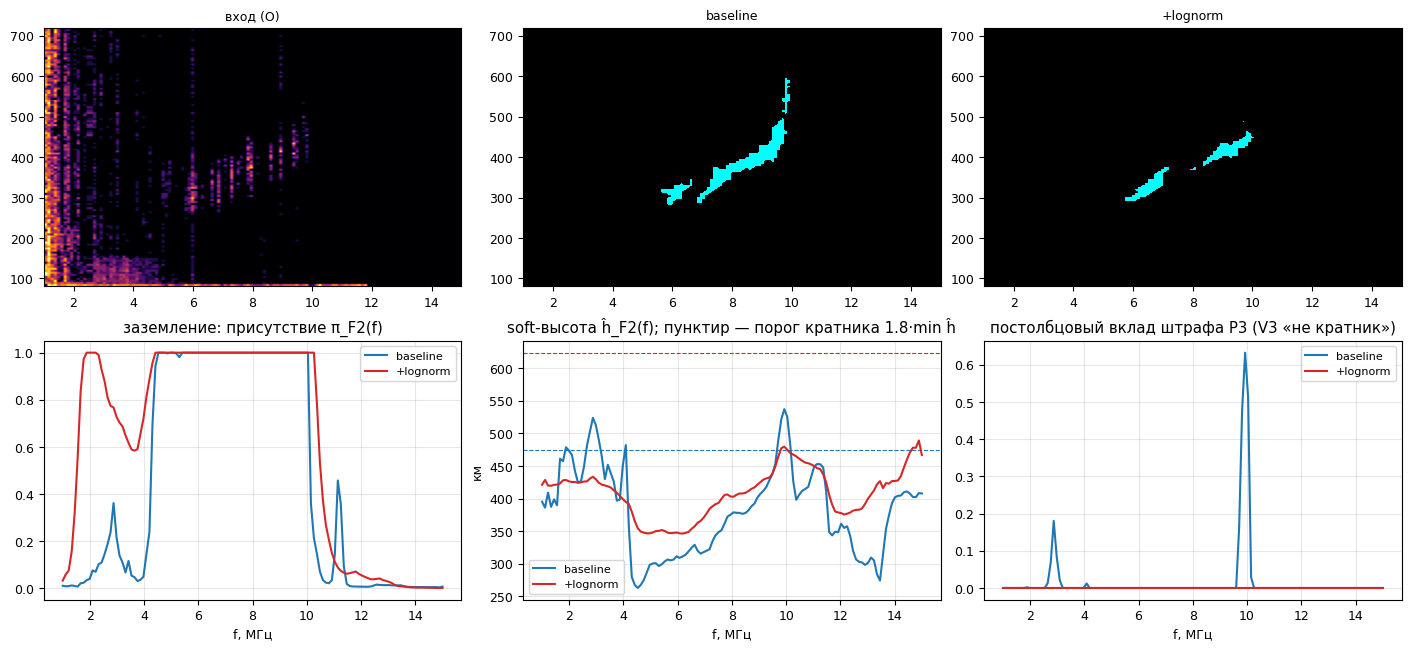

У baseline масса F2 висит и на кратнике (высоты выше пунктира -> ненулевой штраф); +lognorm стянул присутствие к основному следу — штраф около нуля.


In [7]:
diffs = [(((preds['baseline'][k]==1) ^ (preds['+lognorm'][k]==1)).sum(), k) for k in range(len(VA))]
k = sorted(diffs, reverse=True)[0][1]; i = VA[k]
x1 = torch.tensor(X_u8[i:i+1], dtype=torch.float32).div_(255)
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4), constrained_layout=True)
for c, (img, ttl, cm, kw) in enumerate([(X_u8[i, 0], "вход (O)", "inferno", {}),
        (preds["baseline"][k], "baseline", cm_y, dict(vmin=0, vmax=4)),
        (preds["+lognorm"][k], "+lognorm", cm_y, dict(vmin=0, vmax=4))]):
    axes[0, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[1, 15, 80, 720], **kw)
    axes[0, c].set_title(ttl, fontsize=9)
for name, col in [("baseline", "tab:blue"), ("+lognorm", "tab:red")]:
    net = runs[name][0]
    with torch.no_grad():
        lg1 = net(x1)
    pres, h_soft, h_mean, present = readouts(lg1)
    pf2 = pres[0, iF2].numpy(); hf2 = h_soft[0, iF2].numpy()
    hmin = float(h_soft[0, iF2].min())
    axes[1, 0].plot(f_axis, pf2, color=col, label=name)
    axes[1, 1].plot(f_axis, hf2, color=col, label=name)
    axes[1, 1].axhline(1.8 * hmin, color=col, ls="--", lw=.8)
    axes[1, 2].plot(f_axis, pf2 * np.maximum(0, (hf2 - 1.8 * hmin) / 100), color=col, label=name)
axes[1, 0].set(title="заземление: присутствие π_F2(f)", xlabel="f, МГц")
axes[1, 1].set(title="soft-высота ĥ_F2(f); пунктир — порог кратника 1.8·min ĥ", xlabel="f, МГц", ylabel="км")
axes[1, 2].set(title="постолбцовый вклад штрафа P3 (V3 «не кратник»)", xlabel="f, МГц")
for ax in axes[1]: ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()
print("У baseline масса F2 висит и на кратнике (высоты выше пунктира -> ненулевой штраф);"
      " +lognorm стянул присутствие к основному следу — штраф около нуля.")

### 4.0b. Аудит полноты: какие формы онтологии покрыты релаксацией

Онтология содержит 24 формы. Дифференцируемая релаксация возможна не для всех — часть форм
проверяет то, чего в маске классов просто нет (лучи, X-следы, буквы качества, гигиену данных).
Принцип разделения: **геометрия следов** → релаксация в лоссе; **всё остальное** → только
жёсткий SHACL-гейт (`validate_scene` прогоняет ВСЕ формы без исключения — покрытие гейта 100 %).

In [8]:
audit = pd.DataFrame([
 ("H0–H5", "гигиена литералов/привязок", "—", "да (стадия A)", "проверка данных, не геометрии — в тензорах нечему нарушаться"),
 ("S1", "МПЧ убывает с кратностью", "НЗ: S1-пропозиция", "да", ""),
 ("S2", "задержка растёт с кратностью", "НЗ: S2-пропозиция", "да", ""),
 ("S3", "верхний луч только при нижнем", "—", "да", "классы масок не различают лучи (нижний+верхний = один класс)"),
 ("S4", "задержка растёт с высотой слоя", "ВЗ: P1 (порядок высот)", "да", ""),
 ("S5", "два следа != одна мода", "архитектурно (argmax)", "да (H1)", "softmax в пикселе исключает двойную принадлежность"),
 ("S6", "задержка верхнего луча больше", "—", "да", "нет классов лучей"),
 ("V3", "кратник: h'_n = n·h'_1", "ВЗ: P3; НЗ: класс MH", "да", ""),
 ("V4", "O/X: fo^2 = fx(fx-fB)", "—", "да", "X-канал есть на входе, но X-следов нет в целях; кандидат v0.4"),
 ("Q1", "порядок foE < foF1 < foF2", "ВЗ: P4 (НОВОЕ)", "да", "Es исключён — предельная частота (Ф-01)"),
 ("Q2", "fbEs <= foEs", "—", "да", "fbEs не ридаутится из маски (нужен анализ экранирования)"),
 ("Q3", "fxI >= foF2", "—", "да", "нужен X-след"),
 ("Q4–Q7", "буквы качества, условие G", "—", "да", "метаданные качества, сеть их не предсказывает; кандидат — голова качества"),
 ("Q8–Q10", "полнота/аннотации", "—", "да", "уровень оформления данных"),
 ("(нет формы)", "связность следа (РД §7.3.7)", "ВЗ и НЗ: P2", "НЕТ", "обратный разрыв: пропозиция есть, SHACL-формы нет — кандидат S7 для онтологии 0.4"),
], columns=["форма", "что проверяет", "релаксация в лоссе", "в гейте", "комментарий"])
display(audit.set_index("форма"))
print("Итог аудита: 6 групп форм имеют дифференцируемые релаксации (S1, S2, S4, V3, Q1 + архитектурная S5),")
print("гейт покрывает 100% форм; P2 (связность) — единственная пропозиция без SHACL-двойника.")

,что проверяет,релаксация в лоссе,в гейте,комментарий
форма,,,,
H0–H5,гигиена литералов/привязок,—,да (стадия A),"проверка данных, не геометрии — в тензорах неч..."
S1,МПЧ убывает с кратностью,НЗ: S1-пропозиция,да,
S2,задержка растёт с кратностью,НЗ: S2-пропозиция,да,
S3,верхний луч только при нижнем,—,да,классы масок не различают лучи (нижний+верхний...
S4,задержка растёт с высотой слоя,ВЗ: P1 (порядок высот),да,
S5,два следа != одна мода,архитектурно (argmax),да (H1),softmax в пикселе исключает двойную принадлежн...
S6,задержка верхнего луча больше,—,да,нет классов лучей
V3,кратник: h'_n = n·h'_1,ВЗ: P3; НЗ: класс MH,да,
V4,O/X: fo^2 = fx(fx-fB),—,да,"X-канал есть на входе, но X-следов нет в целях..."


Итог аудита: 6 групп форм имеют дифференцируемые релаксации (S1, S2, S4, V3, Q1 + архитектурная S5),
гейт покрывает 100% форм; P2 (связность) — единственная пропозиция без SHACL-двойника.


### 4.1. SHACL-гейт (Q3): браковка, диагностика учителя и **гейт как фильтр**

Предсказание → ридауты характеристик и мод → RDF-сцена → `validate_scene()`. Три роли гейта:
1) **браковка** физически невозможных интерпретаций на инференсе;
2) **диагностика учителя**: ARTIST-сцены через тот же гейт (santy-check согласованности);
3) **фильтр качества**: если гейт осмыслен, у прошедших его предсказаний ошибка foF2 должна
   быть меньше, чем у не прошедших, — проверяем это напрямую.

In [9]:
KIND = {1: ("CriticalFrequencyDatum", "F2"), 2: ("CriticalFrequencyDatum", "F1"),
        3: ("CriticalFrequencyDatum", "E"), 4: ("LimitFrequencyDatum", "Es")}

def scene_from_pred(pm, name):
    g = Graph(); ion = IONO["p_" + name]
    g.add((ion, RDF.type, IONO.VerticalIonogram)); g.add((ion, IONO.hasGyroFrequency, vd.dec(1.3)))
    for ci, (cls, layer) in KIND.items():
        fo, hm = fo_readout(pm, ci), hmin_readout(pm, ci)
        if not np.isfinite(fo): continue
        d = IONO[f"p_{name}_c{ci}"]
        for t in [(d, RDF.type, IONO[cls]), (d, IONO.isCharacteristicOf, ion),
                  (d, IONO.refersToLayer, IONO["Layer_" + layer]), (d, IONO.refersToComponent, IONO.ordinary),
                  (d, IONO.hasNumericValue, vd.dec(fo)), (d, IONO.hasUnit, Literal("МГц"))]: g.add(t)
        tr, mo = IONO[f"p_{name}_t{ci}"], IONO[f"p_{name}_m{ci}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode), (mo, IONO.hasHopCount, Literal(1, datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay), (mo, IONO.hasMagnetoionicComponent, IONO.ordinary),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]), (mo, IONO.hasMOFValue, vd.dec(fo)),
                  (mo, IONO.hasMinDelayValue, vd.dec(2 * hm / 299.792458))]: g.add(t)
    return g

N_G = 150; t0 = time.time()
gpick = np.random.default_rng(0).choice(len(VA), N_G, replace=False)
gate_res, pass_fail = [], {}
for name in ["baseline", "+lognorm"]:
    pm = preds[name]; ok_flags = []
    for k in gpick:
        r = vd.validate_scene(scene_from_pred(pm[k], f"{name[1:5]}_{k}"), vocab, verbose=False)
        ok_flags.append(not r["violations"])
    pass_fail[name] = np.array(ok_flags)
    gate_res.append(dict(run=name, наруш=f"{1-np.mean(ok_flags):.0%}"))
nv = sum(bool(vd.validate_scene(scene_from_pred(yv[k], f"a_{k}"), vocab, verbose=False)["violations"]) for k in gpick)
gate_res.append(dict(run="ARTIST (учитель)", наруш=f"{nv/N_G:.0%}"))
print(f"гейт: {time.time()-t0:.0f} с"); display(pd.DataFrame(gate_res).set_index("run"))

# гейт как фильтр: ошибка foF2 у прошедших vs отбракованных (обе модели вместе — больше статистики)
errs, flags = [], []
for name in ["baseline", "+lognorm"]:
    pm = preds[name]
    e = np.array([abs(fo_readout(pm[k]) - meta.foF2.values[VA[k]]) for k in gpick])
    errs.append(e); flags.append(pass_fail[name])
err = np.concatenate(errs); pf = np.concatenate(flags)
okm = np.isfinite(err); err, pf = err[okm], pf[okm]
big = err > 0.3
print(f"\nгейт как фильтр (обе модели, {len(err)} сцен):")
print(f"  ПРОШЕДШИЕ  (n={pf.sum()}): |Δ foF2| медиана {np.median(err[pf]):.2f} МГц, доля ошибок >0.3 МГц {big[pf].mean():.0%}")
print(f"  ОТБРАКОВАННЫЕ (n={(~pf).sum()}): медиана {np.median(err[~pf]):.2f} МГц, доля >0.3 МГц {big[~pf].mean():.0%}")

гейт: 669 с


,наруш
run,
baseline,5%
+lognorm,5%
ARTIST (учитель),0%



гейт как фильтр (обе модели, 244 сцен):
  ПРОШЕДШИЕ  (n=232): |Δ foF2| медиана 0.08 МГц, доля ошибок >0.3 МГц 5%
  ОТБРАКОВАННЫЕ (n=12): медиана 0.10 МГц, доля >0.3 МГц 0%


## 5. Синтетика НЗ (Q1). Теория: три теоремы эквивалентности

Для плоскослоистой (или сферически-слоистой) изотропной ионосферы:

1. **Теорема Брейта–Тьюва**: групповой путь наклонного луча = длина ломаной через вершину на
   действующей высоте $h'$ (задержка — как при скорости $c$ по треугольнику).
2. **Теорема Мартина об эквивалентном пути**: $h'_{нз}(f_{нз}) = h'_в(f_в)$.
3. **Закон секанса (Мартина)**: $f_{нз} = f_в\sec\varphi_0$ — отражение происходит там, где
   $n = \sin\varphi_0$ (а не $n=0$), т.е. от того же уровня плазменной частоты при частоте
   в $\sec\varphi_0$ раз выше.

**Геометрия.** Плоская Земля (до $D\lesssim500$ км):
$\sec\varphi_0=\sqrt{1+(D/2h')^2}$, $P'=\sqrt{D^2+4h'^2}$. **Сферическая** (обязательна дальше;
$R=6371$ км, $\theta=D/2nR$ — половинный угол скачка):

$$\tan\Delta=\frac{\cos\theta-\frac{R}{R+h'}}{\sin\theta},\quad
\sin\varphi_0=\frac{R\cos\Delta}{R+h'},\quad
P'=2n\sqrt{R^2+(R+h')^2-2R(R+h')\cos\theta}$$

При $\tan\Delta\le0$ вершина за горизонтом — мода геометрически невозможна (так 1E сама
исчезает при $D\gtrsim2000$ км). Поправочный множитель $k\approx1.0$–$1.2$ (кривизна слоя,
«база слоя vs действующая высота») мы не вводим — и в §5.2 измеряем его сами.

**Немонотонность** $f_{нз}(f_в)$ даёт «нос» МПЧ и две ветви (нижний/верхний-педерсеновский
лучи); каждый слой даёт свой нос; кратники ($D/n$, $P'\times n$) получают меньшие МПЧ (S1) и
большие задержки (S2) по построению.

**Оговорки честности** (важны для чтения результатов):
- *Точка отражения — фикция*: вершина треугольника виртуальна; реально волна замедляется в
  слое и растянута по горизонтали на сотни км (сильнее всего у педерсеновского луча — поэтому
  верхняя ветвь синтетики наименее надёжна).
- *Зонд — в середине трассы*, а формально ионосфера должна быть однородна вдоль всей трассы;
  на 3000 км с градиентом/терминатором ошибка МПЧ достигает 10–20 %.
- *Многоскачковые моды*: точки отражения разнесены на $D/n$; одна вертикальная ионограмма
  описывает их лишь в предположении однородности; отражение от земли между скачками в закон
  секанса не входит.
- *Магнитное поле*: для X-моды теорема Мартина приближённа (сдвиг $\approx f_B/2$) — нужна
  магнитоионная трассировка (Джонс–Стивенсон; PHaRLAP, IONORT).
- *Долина E–F* у ARTIST модельная — систематика в $P'$ F-ветви.

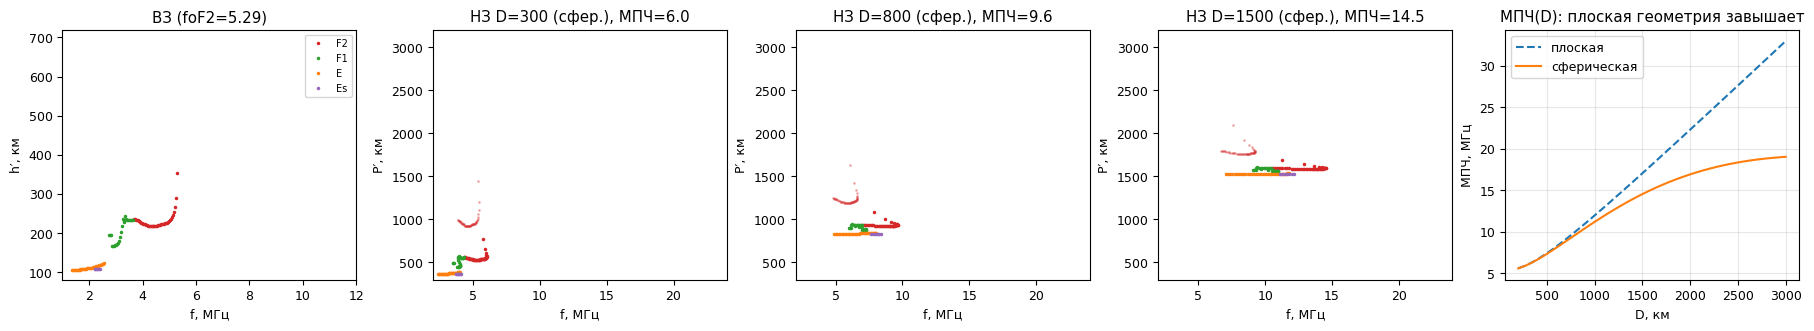

In [10]:
# демо: профиль -> семейство наклонных ионограмм; плоская vs сферическая
sao = dfm.read_sao(sorted(glob.glob(f"{ROOT}/data/corpus/MO155/*/*/scaled/*.SAO"))[5000])
colors = dict(F2="tab:red", F1="tab:green", E="tab:orange", Es="tab:purple")
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), constrained_layout=True)
for cls, key in obs.SAO_TRACES.items():
    fq, vh = sao.get(f"{key}_freq"), sao.get(f"{key}_vh")
    if fq is not None and len(fq): axes[0].plot(fq, vh, ".", ms=3, color=colors[cls], label=cls)
axes[0].set(title=f"ВЗ (foF2={sao['scaled']['foF2']:.2f})", xlabel="f, МГц", ylabel="h′, км",
            xlim=(1, 12), ylim=(80, 720)); axes[0].legend(fontsize=7)
for j, D in enumerate([300, 800, 1500], 1):
    for cls, key in obs.SAO_TRACES.items():
        fq, vh = sao.get(f"{key}_freq"), sao.get(f"{key}_vh")
        if fq is None or not len(fq): continue
        f1, p1 = obs.oblique_transform(fq, vh, D, 1)
        axes[j].plot(f1, p1, ".", ms=3, color=colors[cls])
    f2, p2 = obs.oblique_transform(sao["F2o_freq"], sao["F2o_vh"], D, 2)
    axes[j].plot(f2, p2, ".", ms=2, color="tab:red", alpha=.3)
    axes[j].set(title=f"НЗ D={D} (сфер.), МПЧ={obs.muf(sao['F2o_freq'], sao['F2o_vh'], D):.1f}",
                xlabel="f, МГц", ylabel="P′, км", xlim=(2, 24), ylim=(300, 3200))
Ds = np.linspace(200, 3000, 40)
for geom, ls in [("flat", "--"), ("spherical", "-")]:
    axes[4].plot(Ds, [obs.muf(sao["F2o_freq"], sao["F2o_vh"], D, 1, geom) for D in Ds], ls,
                 label="плоская" if geom == "flat" else "сферическая")
axes[4].set(title="МПЧ(D): плоская геометрия завышает", xlabel="D, км", ylabel="МПЧ, МГц")
axes[4].legend(); axes[4].grid(alpha=.3)
plt.show()

### 5.1. Валидация №1: против ARTIST M3000F2 (независимая реализация той же физики)

ARTIST вычисляет $M(3000)F2$ **методом кривых передачи Смита** — то же преобразование
ВЗ→НЗ, реализованное в 1939 г. графически. Проверка: наш $\mathrm{МПЧ}(3000)$ по сферическому
секансу должен совпасть с $M(3000)F2\times f_oF2$ с точностью до множителя кривизны $k$.

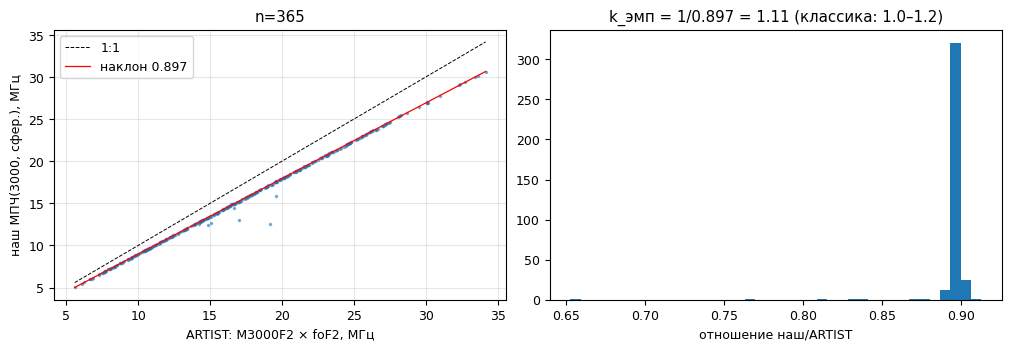

медиана отношения 0.897, IQR 0.003 — систематика есть (множитель кривизны k), СЛУЧАЙНОГО разброса почти нет: наша реализация детерминированно согласована с кривыми передачи ARTIST


In [11]:
fs_all = sorted(glob.glob(f"{ROOT}/data/corpus/*/*/*/scaled/*.SAO"))
rng = np.random.default_rng(0); ours, arts = [], []
for f in rng.choice(fs_all, 400, replace=False):
    try:
        a, b = obs.muf3000_check(dfm.read_sao(f))
        if np.isfinite(a) and np.isfinite(b) and b > 0: ours.append(a); arts.append(b)
    except Exception: pass
ours, arts = np.array(ours), np.array(arts); ratio = ours / arts
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(arts, ours, ".", ms=3, alpha=.5); lim = [arts.min(), arts.max()]
axes[0].plot(lim, lim, "k--", lw=.7, label="1:1")
axes[0].plot(lim, [l*np.median(ratio) for l in lim], "r-", lw=.9, label=f"наклон {np.median(ratio):.3f}")
axes[0].set(xlabel="ARTIST: M3000F2 × foF2, МГц", ylabel="наш МПЧ(3000, сфер.), МГц",
            title=f"n={len(ours)}"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].hist(ratio, bins=40); axes[1].set(xlabel="отношение наш/ARTIST",
    title=f"k_эмп = 1/{np.median(ratio):.3f} = {1/np.median(ratio):.2f} (классика: 1.0–1.2)")
plt.show()
print(f"медиана отношения {np.median(ratio):.3f}, IQR {np.percentile(ratio,75)-np.percentile(ratio,25):.3f}"
      f" — систематика есть (множитель кривизны k), СЛУЧАЙНОГО разброса почти нет:"
      f" наша реализация детерминированно согласована с кривыми передачи ARTIST")

### 5.2. Валидация №2: против точной трассировки по истинному профилю (Бугер)

Закон секанса — приближение первого порядка. «Точный вариант» — трассировка по профилю
$N(h)$ из NHPC ARTIST с инвариантом Бугера для сферической стратификации:
$$n(h)(R+h)\sin\varphi(h)=R\sin\varphi_0,\qquad
D=2R\!\!\int\frac{\tan\varphi}{r}dr,\qquad P'=2\!\!\int\frac{dr}{n\cos\varphi}$$
(групповой показатель в изотропной плазме $=1/n$; у точки отражения интегралы имеют
интегрируемую особенность — квадратура со сгущением). Для каждой $f$ решение $D(f,\varphi_0)=D$
имеет два корня — нижний и верхний лучи; у МПЧ они сливаются.

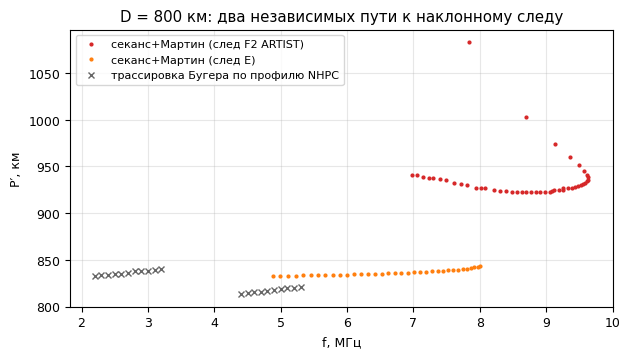

Расхождения ожидаемы у носа (педерсеновский луч чувствителен к профилю) и в E–F долине (у ARTIST она модельная)


In [12]:
# веер лучей по профилю: точки с D≈800 км поверх секансного следа
ph, pf = sao["profile_h"], sao["profile_fp"]
D0 = 800.0; pts = []
for f_t in np.arange(2.2, 5.4, 0.1):
    for phi0 in np.arange(35, 89.5, 0.7):
        D, P = obs.bouguer_trace(ph, pf, f_t, phi0, n_int=1200)
        if np.isfinite(D) and abs(D - D0) < 15: pts.append((f_t, P))
pts = np.array(pts)
f1, p1 = obs.oblique_transform(sao["F2o_freq"], sao["F2o_vh"], D0, 1)
fe, pe = obs.oblique_transform(sao["Eo_freq"], sao["Eo_vh"], D0, 1)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(f1, p1, ".", ms=4, color="tab:red", label="секанс+Мартин (след F2 ARTIST)")
ax.plot(fe, pe, ".", ms=4, color="tab:orange", label="секанс+Мартин (след E)")
if len(pts): ax.plot(pts[:, 0], pts[:, 1], "x", ms=4, color="k", alpha=.6, label="трассировка Бугера по профилю NHPC")
ax.set(xlabel="f, МГц", ylabel="P′, км", title=f"D = {D0:.0f} км: два независимых пути к наклонному следу")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.show()
print("Расхождения ожидаемы у носа (педерсеновский луч чувствителен к профилю) и в E–F долине (у ARTIST она модельная)")

## 6. Нейрорендерер шума (Q1, центральный элемент)

Растеризованная маска — «идеальная» ионограмма. Реальное сырьё — разреженный спекл эха + фон +
RFI-полосы. Вместо ручной модели шума учим **обратное отображение** на 29 тыс. реальных пар:
U-Net, вход — one-hot маски + координаты + канал шума, выход на каждую поляризацию —
вероятность активности $p$ и амплитуда $a$:
$$\mathcal{L}=\sum_{pol}\mathrm{BCE}(p,\ [X>0]) + \|a-X\|_1\cdot[X>0],\qquad
X_{синт}=[u<p]\cdot a,\ u\sim U(0,1).$$
Сэмплирование даёт спекл и стохастичность (каждый батч — новая реализация = бесконечная
аугментация, ср. domain randomization). Геометрию диктует входная маска, текстуру — обучение,
поэтому рендерер переносится с ВЗ-масок на НЗ-маски. Оцениваем тремя способами: глазами (6.1),
статистиками шума (6.2) и **цикл-тестом интерпретируемости** (6.3).

  рендерер ep0: loss 1.882


  рендерер ep1: loss 1.731


  рендерер ep2: loss 1.699
160 с


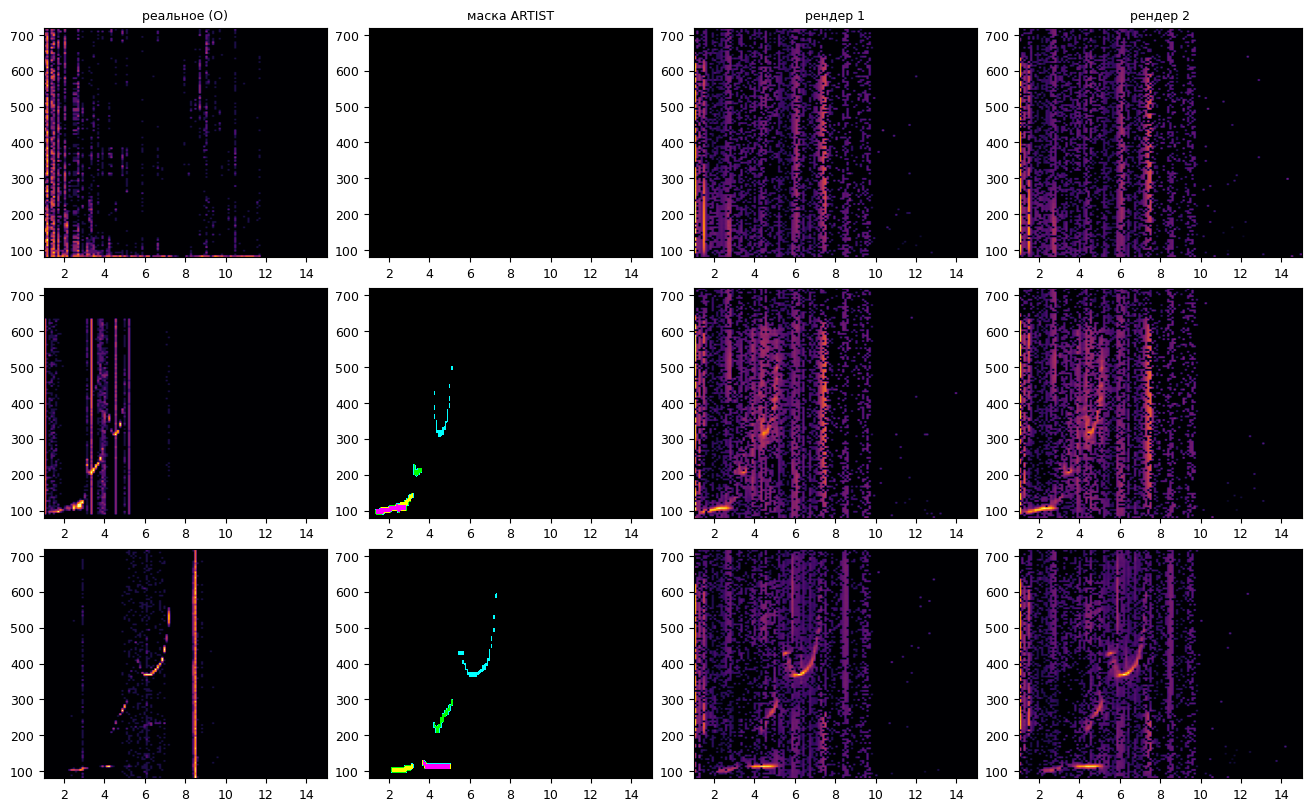

In [13]:
def render_input(mask5, dev):
    B, H, W = mask5.shape
    oh = Fn.one_hot(mask5.clamp(0, 4), 5).permute(0, 3, 1, 2).float()
    hh = torch.linspace(0, 1, H, device=dev).view(1,1,H,1).expand(B,1,H,W)
    ww = torch.linspace(0, 1, W, device=dev).view(1,1,1,W).expand(B,1,H,W)
    return torch.cat([oh.to(dev), hh, ww, torch.rand(B, 1, H, W, device=dev)], 1)

renderer = UNet(8, 4).to(DEV)
opt = torch.optim.Adam(renderer.parameters(), 2e-3)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(8.0, device=DEV))
t0 = time.time()
for ep in range(3):
    tot = n = 0
    for _ in range(len(tr_i) // 64):
        j = tr_i[np.random.randint(0, len(tr_i), 64)]
        x = torch.tensor(X_u8[j], dtype=torch.float32, device=DEV).div_(255)
        y = torch.tensor(Y_all[j], device=DEV).long()
        out = renderer(render_input(y, DEV)); loss = 0
        for c in range(2):
            p_log, a = out[:, 2*c], out[:, 2*c+1]
            act = (x[:, c] > 0).float()
            loss = loss + bce(p_log, act) + ((a - x[:, c]).abs() * act).sum() / (act.sum() + 1)
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item(); n += 1
    print(f"  рендерер ep{ep}: loss {tot/n:.3f}")
print(f"{time.time()-t0:.0f} с")

@torch.no_grad()
def render_sample(mask5_t):
    out = renderer(render_input(mask5_t, DEV)); xs = []
    for c in range(2):
        p = torch.sigmoid(out[:, 2*c]); a = out[:, 2*c+1].clamp(0, 1)
        xs.append((torch.rand_like(p) < p).float() * a)
    return torch.stack(xs, 1)

# 6.1 глазами: реальное сырьё vs две реализации
pick = va_i[[100, 2000, 5000]]
mt = torch.tensor(Y_all[pick], device=DEV).long()
s1, s2 = render_sample(mt).cpu().numpy(), render_sample(mt).cpu().numpy()
fig, axes = plt.subplots(3, 4, figsize=(13, 8), constrained_layout=True)
for r, i in enumerate(pick):
    for c, (img, ttl, cm) in enumerate([(X_u8[i, 0]/255, "реальное (O)", "inferno"),
            (Y_all[i], "маска ARTIST", cm_y), (s1[r, 0], "рендер 1", "inferno"), (s2[r, 0], "рендер 2", "inferno")]):
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[1, 15, 80, 720])
        if r == 0: axes[r, c].set_title(ttl, fontsize=9)
plt.show()

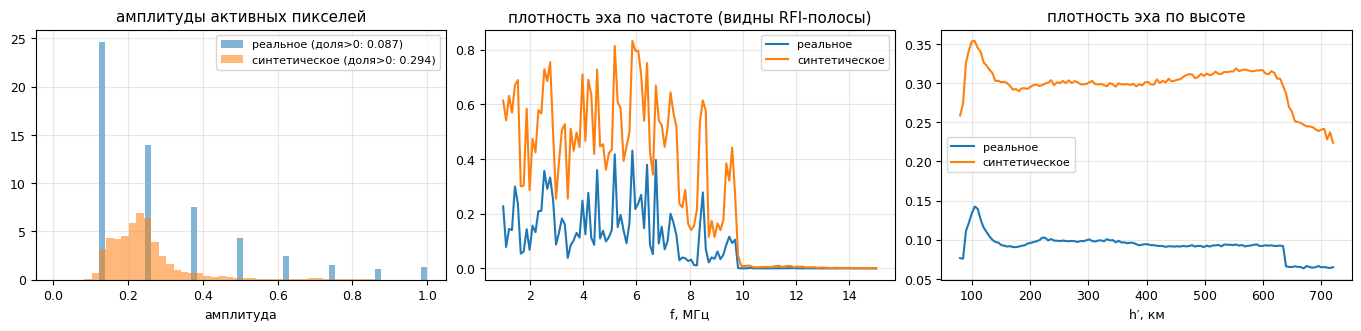

In [14]:
# 6.2 статистики шума: реальное vs синтетическое (на тех же val-масках)
sub = va_i[np.random.default_rng(1).choice(len(va_i), 300, replace=False)]
Xr = X_u8[sub].astype(np.float32) / 255
Xs = torch.cat([render_sample(torch.tensor(Y_all[sub[k:k+100]], device=DEV).long()).cpu()
                for k in range(0, 300, 100)]).numpy()
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2), constrained_layout=True)
for X, lbl in [(Xr, "реальное"), (Xs, "синтетическое")]:
    v = X[X > 0].ravel()
    axes[0].hist(v, bins=50, alpha=.55, density=True, label=f"{lbl} (доля>0: {(X>0).mean():.3f})")
    axes[1].plot(f_axis, (X[:, 0] > 0).mean((0, 1)), label=lbl)
    axes[2].plot(h_axis, (X[:, 0] > 0).mean((0, 2)), label=lbl)
axes[0].set(title="амплитуды активных пикселей", xlabel="амплитуда"); axes[0].legend(fontsize=8)
axes[1].set(title="плотность эха по частоте (видны RFI-полосы)", xlabel="f, МГц"); axes[1].legend(fontsize=8)
axes[2].set(title="плотность эха по высоте", xlabel="h′, км"); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=.3)
plt.show()

In [15]:
# 6.3 сим2реал в ОБЕ стороны — главный тест качества рендерера
Yref = Y_all[sub].astype(np.int64)

def eval_net(net, X_src, Y_ref):
    net = net.to(DEV).eval(); pms = []
    with torch.no_grad():
        for k in range(0, len(X_src), 128):
            x = torch.as_tensor(X_src[k:k+128], dtype=torch.float32, device=DEV)
            if x.max() > 1.5: x = x / 255
            pms.append(net(x).argmax(1).cpu().numpy())
    pm = np.concatenate(pms); net.cpu()
    iou = ((pm == 1) & (Y_ref == 1)).sum() / ((pm == 1) | (Y_ref == 1)).sum()
    fo_p = np.array([fo_readout(pm[k]) for k in range(len(pm))])
    fo_r = np.array([fo_readout(Y_ref[k]) for k in range(len(pm))])
    ok = np.isfinite(fo_p) & np.isfinite(fo_r)
    return iou, np.median(np.abs(fo_p[ok] - fo_r[ok]))

# направление 1: сеть, обученная на РЕАЛЬНОМ (baseline), читает РЕНДЕР
v_net = runs["baseline"][0]
iou_rr, e_rr = eval_net(v_net, X_u8[sub], Yref)
iou_rs, e_rs = eval_net(v_net, Xs, Yref)
# направление 2 (главное для конвейера синтетики): сеть, ОБУЧЕННАЯ НА РЕНДЕРЕ, читает РЕАЛЬНОЕ
torch.manual_seed(0)
syn_net = UNet(2, 5).to(DEV); opt = torch.optim.Adam(syn_net.parameters(), 2e-3)
ce = nn.CrossEntropyLoss(weight=ce_w)
for ep in range(3):
    for _ in range(len(tr_i) // 64):
        j = tr_i[np.random.randint(0, len(tr_i), 64)]
        y = torch.tensor(Y_all[j], device=DEV).long()
        x = render_sample(y)
        opt.zero_grad(); ce(syn_net(x), y).backward(); opt.step()
iou_sr, e_sr = eval_net(syn_net, X_u8[sub], Yref)
iou_ss, e_ss = eval_net(syn_net, Xs, Yref)
res_s2r = pd.DataFrame([
    dict(net="обучена на РЕАЛЬНОМ", на_реальном=f"IoU {iou_rr:.2f} | {e_rr:.2f} МГц", на_рендере=f"IoU {iou_rs:.2f} | {e_rs:.2f} МГц"),
    dict(net="обучена на РЕНДЕРЕ",  на_реальном=f"IoU {iou_sr:.2f} | {e_sr:.2f} МГц", на_рендере=f"IoU {iou_ss:.2f} | {e_ss:.2f} МГц"),
]).set_index("net")
display(res_s2r)
print("Честное чтение: диагональ (обучение и тест в одном домене) — верхняя планка;")
print("клетка «на РЕНДЕРЕ обучена -> на РЕАЛЬНОМ» — рабочая мера пригодности синтетики: ")
print("если она близка к диагонали, рендерер передаёт интерпретируемое содержание;")
print("большой разрыв = ключевое ограничение, и внешний НЗ-тест обязателен.")

,на_реальном,на_рендере
net,,
обучена на РЕАЛЬНОМ,IoU 0.37 | 0.11 МГц,IoU 0.10 | 1.98 МГц
обучена на РЕНДЕРЕ,IoU 0.17 | 1.54 МГц,IoU 0.83 | 0.00 МГц


Честное чтение: диагональ (обучение и тест в одном домене) — верхняя планка;
клетка «на РЕНДЕРЕ обучена -> на РЕАЛЬНОМ» — рабочая мера пригодности синтетики: 
если она близка к диагонали, рендерер передаёт интерпретируемое содержание;
большой разрыв = ключевое ограничение, и внешний НЗ-тест обязателен.


## 7. Эксперимент 2: НЗ-модель на синтетике

Датасет: 27 тыс. профилей × D∈{300, 800, 1500} км (сферическая геометрия), классы
BG/F2/F1/E/Es/**MH** (кратник 2F2), точные МПЧ-метки. Вход — свежий рендер каждый батч
(MH подаётся рендереру как F2). Логика НЗ — релаксации исходных НЗ-форм онтологии с детачем
опорной стороны:
$$S_1:\ \mathrm{pen}\big(f_{max}^{MH}-\underbrace{f_{max}^{F2}}_{\text{detach}}+0.02\big)\qquad
S_2:\ \mathrm{pen}\big(\underbrace{\bar d^{F2}}_{\text{detach}}+150/2900-\bar d^{MH}\big)\qquad
P_2:\ \text{связность}$$
($f_{max}$ — logsumexp-заземление максимальной частоты присутствия). Дополнительная
инвариантная метрика — **отношение МПЧ кратника к основному** (Пономарчук и др., 2013:
квазиинвариант НЗ, слабо зависящий от вариаций ионосферы).

НЗ-синтетика: 27170 × 3 D (train 20273 / val 6897)


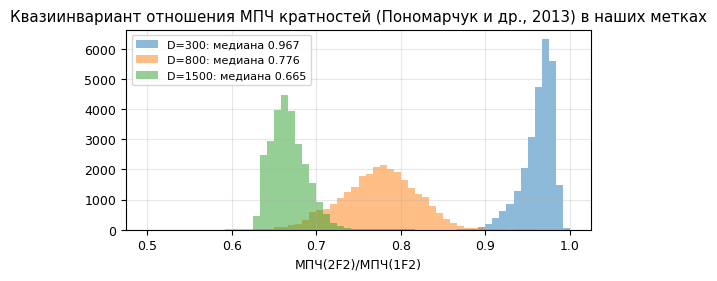

In [16]:
OCACHE = f"{ROOT}/data/oblique_cache"
ometa = pd.read_csv(f"{OCACHE}/meta.csv").sort_values(["shard", "idx"]).reset_index(drop=True)
Yo = np.concatenate([np.load(s)["Y"] for s in sorted(glob.glob(f"{OCACHE}/shard_*.npz"))])  # int8
stem2row = {s: i for i, s in enumerate(meta.stem)}
ometa["vrow"] = ometa.stem.map(stem2row)
keep = ometa.vrow.notna().to_numpy()
Yo = Yo[keep]; ometa = ometa[keep].reset_index(drop=True)
o_val = val_mask[ometa.vrow.astype(int).to_numpy()]
otr_i, ova_i = np.where(~o_val)[0], np.where(o_val)[0]
D_SET = obs.D_SET
print(f"НЗ-синтетика: {len(Yo)} × {Yo.shape[1]} D (train {len(otr_i)} / val {len(ova_i)})")
# инвариант Пономарчука в МЕТКАХ: отношение МПЧ(2F2)/МПЧ(1F2)
fig, ax = plt.subplots(figsize=(6, 2.6))
for D in D_SET:
    r = (ometa[f"muf_MH_D{int(D)}"] / ometa[f"muf_F2_D{int(D)}"]).dropna()
    ax.hist(r, bins=60, range=(0.5, 1.0), alpha=.5, label=f"D={int(D)}: медиана {r.median():.3f}")
ax.set(xlabel="МПЧ(2F2)/МПЧ(1F2)", title="Квазиинвариант отношения МПЧ кратностей (Пономарчук и др., 2013) в наших метках")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.show()

In [17]:
iF2o, iMH = 0, 4
f_norm = torch.linspace(0, 1, 128)

def ob_readouts(logits):
    p = logits.softmax(1)
    mass = p[:, 1:].sum(2)
    pres = (mass / 3.0).clamp(0, 1)
    rows = torch.arange(128, dtype=torch.float32, device=logits.device).view(1, 1, -1, 1)
    d_soft = (p[:, 1:] * rows).sum(2) / (mass + 1e-6) / 127.0
    w = pres / (pres.sum(-1, keepdim=True) + 1e-6)
    d_mean = (d_soft * w).sum(-1)
    fmax = torch.logsumexp(torch.log(pres + 1e-6) + 12 * f_norm.to(logits.device), -1) / 12
    return pres, d_soft, d_mean, fmax, pres.mean(-1)

def ob_logic_loss(logits, variant="lognorm"):
    pres, d_soft, d_mean, fmax, present = ob_readouts(logits)
    pen = (lambda u: Fn.relu(u)) if variant == "hinge" else (lambda u: Fn.softplus(u, beta=2.0))
    g = (present[:, iF2o] * present[:, iMH]).detach()
    S1 = g * pen(fmax[:, iMH] - fmax[:, iF2o].detach() + 0.02)
    S2 = g * pen(d_mean[:, iF2o].detach() - d_mean[:, iMH] + 150/2900)
    dh = (d_soft[:, :, 1:] - d_soft[:, :, :-1]).abs()
    wc = (pres[:, :, 1:] * pres[:, :, :-1]).detach()
    P2 = (wc * pen(dh - 3/128)).sum((1, 2)) / (wc.sum((1, 2)) + 1e-6)
    return (S1 + S2 + P2).mean()

MH2F2 = torch.tensor([0, 1, 2, 3, 4, 1])
def ob_batch(idx, bs, rng):
    j = idx[rng.integers(0, len(idx), bs)]
    d_pick = rng.integers(0, 3, bs)
    y = torch.tensor(Yo[j, d_pick], device=DEV).long()
    return render_sample(MH2F2.to(DEV)[y]), y

ce6 = nn.CrossEntropyLoss(weight=torch.tensor([0.05, 1, 1, 1, 1, 1.], device=DEV))
def train_ob(name, logic=None, lam=0.5, epochs=5, steps=300):
    torch.manual_seed(1); rng = np.random.default_rng(1)
    net = UNet(2, 6).to(DEV); opt = torch.optim.Adam(net.parameters(), 2e-3)
    for ep in range(epochs):
        tot = 0
        for _ in range(steps):
            x, y = ob_batch(otr_i, 64, rng)
            lg = net(x); loss = ce6(lg, y)
            if logic: loss = loss + lam * ob_logic_loss(lg, logic)
            opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
        print(f"  [{name}] ep{ep}: train {tot/steps:.3f}")
    return net
t0 = time.time()
ob_runs = {"baseline": train_ob("baseline"), "+lognorm": train_ob("+lognorm", logic="lognorm")}
print(f"обучение НЗ: {time.time()-t0:.0f} с")

  [baseline] ep0: train 0.330


  [baseline] ep1: train 0.035


  [baseline] ep2: train 0.023


  [baseline] ep3: train 0.018


  [baseline] ep4: train 0.016


  [+lognorm] ep0: train 0.696


  [+lognorm] ep1: train 0.218


  [+lognorm] ep2: train 0.203


  [+lognorm] ep3: train 0.197


  [+lognorm] ep4: train 0.196
обучение НЗ: 574 с


,МПЧ_F2_RMSE,МПЧ_2F2_RMSE,IoU_F2
run,,,
baseline,0.90,0.36,0.801
+lognorm,0.91,0.49,0.791
ВЗ-модель zero-shot,6.31,NaN,0.080


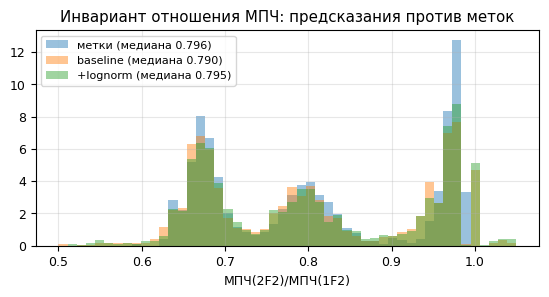

In [18]:
fob_axis, p_axis = obs.fob_axis, obs.p_axis
def hard_fmax(pm, ci):
    cols = np.where((pm == ci).sum(0) >= 2)[0]
    return fob_axis[cols[-1]] if len(cols) else np.nan
def hard_pmin(pm, ci):
    rows = np.where((pm == ci).any(1))[0]
    return p_axis[int(np.percentile(rows, 5))] if len(rows) else np.nan

rngv = np.random.default_rng(7); NV = 2400
vi = ova_i[rngv.integers(0, len(ova_i), NV)]; vD = rngv.integers(0, 3, NV)
torch.manual_seed(7)
Xv = torch.cat([render_sample(MH2F2.to(DEV)[torch.tensor(Yo[vi[k:k+256], vD[k:k+256]], device=DEV).long()]).cpu()
                for k in range(0, NV, 256)])
Yv = Yo[vi, vD].astype(np.int64)
muf1 = np.array([ometa.iloc[vi[k]][f"muf_F2_D{int(D_SET[vD[k]])}"] for k in range(NV)])
muf2 = np.array([ometa.iloc[vi[k]][f"muf_MH_D{int(D_SET[vD[k]])}"] for k in range(NV)])
rows, preds_ob = [], {}
for name, net in ob_runs.items():
    with torch.no_grad():
        pm = torch.cat([net(Xv[k:k+256].to(DEV)).argmax(1).cpu() for k in range(0, NV, 256)]).numpy()
    net.cpu(); preds_ob[name] = pm
    r = dict(run=name)
    for ci, cls, lab in [(1, "F2", muf1), (5, "2F2", muf2)]:
        fp = np.array([hard_fmax(pm[k], ci) for k in range(NV)])
        ok = np.isfinite(fp) & np.isfinite(lab)
        r[f"МПЧ_{cls}_RMSE"] = round(float(np.sqrt(np.mean((fp[ok]-lab[ok])**2))), 2)
    r["IoU_F2"] = round((((pm==1)&(Yv==1)).sum() / ((pm==1)|(Yv==1)).sum()), 3)
    rows.append(r)
with torch.no_grad():
    v_net.to(DEV); pmv = torch.cat([v_net(Xv[k:k+256].to(DEV)).argmax(1).cpu() for k in range(0, NV, 256)]).numpy(); v_net.cpu()
fp = np.array([hard_fmax(pmv[k], 1) for k in range(NV)]); ok = np.isfinite(fp) & np.isfinite(muf1)
rows.append(dict(run="ВЗ-модель zero-shot", МПЧ_F2_RMSE=round(float(np.sqrt(np.mean((fp[ok]-muf1[ok])**2))), 2),
                 IoU_F2=round((((pmv==1)&(Yv==1)).sum() / ((pmv==1)|(Yv==1)).sum()), 3)))
display(pd.DataFrame(rows).set_index("run"))

# инвариант Пономарчука: предсказанное отношение vs метки
fig, ax = plt.subplots(figsize=(6.5, 2.8))
r_lab = muf2[np.isfinite(muf2) & np.isfinite(muf1)] / muf1[np.isfinite(muf2) & np.isfinite(muf1)]
ax.hist(r_lab, bins=50, range=(0.5, 1.05), alpha=.45, density=True, label=f"метки (медиана {np.median(r_lab):.3f})")
for name, pm in preds_ob.items():
    f1p = np.array([hard_fmax(pm[k], 1) for k in range(NV)])
    f2p = np.array([hard_fmax(pm[k], 5) for k in range(NV)])
    ok = np.isfinite(f1p) & np.isfinite(f2p)
    ax.hist(f2p[ok]/f1p[ok], bins=50, range=(0.5, 1.05), alpha=.45, density=True,
            label=f"{name} (медиана {np.median(f2p[ok]/f1p[ok]):.3f})")
ax.set(xlabel="МПЧ(2F2)/МПЧ(1F2)", title="Инвариант отношения МПЧ: предсказания против меток")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.show()

гейт НЗ: 150 с


,наруш
run,
baseline,2%
+lognorm,4%
метки (аналитика),0%


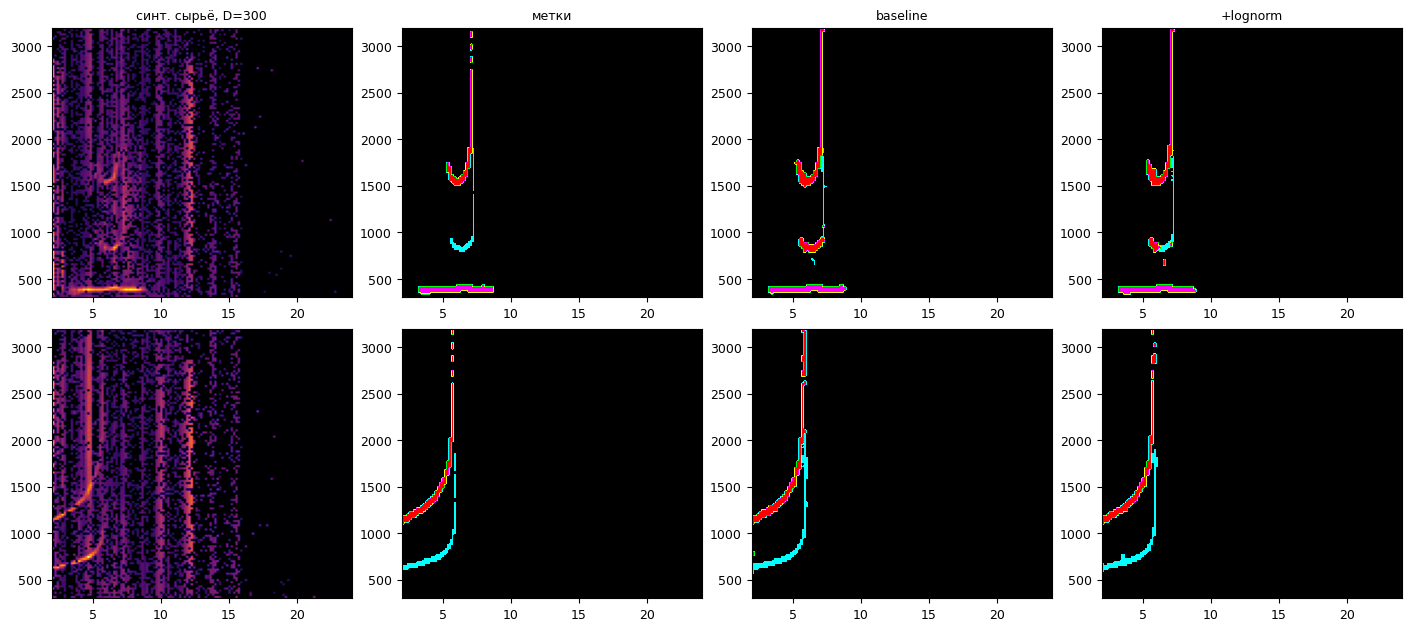

In [19]:
# SHACL-гейт НЗ + качественные примеры
def ob_scene(pm, name):
    g = Graph(); ion = IONO["ob_" + name]
    g.add((ion, RDF.type, IONO.ObliqueIonogram))
    for ci, layer, hop in [(1, "F2", 1), (4, "Es", 1), (5, "F2", 2)]:
        fm, pmn = hard_fmax(pm, ci), hard_pmin(pm, ci)
        if not np.isfinite(fm): continue
        tr, mo = IONO[f"ob_{name}_t{ci}"], IONO[f"ob_{name}_m{ci}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode), (mo, IONO.hasHopCount, Literal(hop, datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay), (mo, IONO.hasMagnetoionicComponent, IONO.ordinary),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]),
                  (mo, IONO.hasMOFValue, vd.dec(fm)), (mo, IONO.hasMinDelayValue, vd.dec(pmn / 299.792458))]:
            g.add(t)
    return g
N_GO = 45; t0 = time.time(); gtab = []
gp = np.random.default_rng(3).choice(NV, N_GO, replace=False)
for name, pm in list(preds_ob.items()) + [("метки (аналитика)", Yv)]:
    nv = sum(bool(vd.validate_scene(ob_scene(pm[k], f"{name[:4]}_{k}"), vocab, verbose=False)["violations"]) for k in gp)
    gtab.append(dict(run=name, наруш=f"{nv/N_GO:.0%}"))
print(f"гейт НЗ: {time.time()-t0:.0f} с"); display(pd.DataFrame(gtab).set_index("run"))

cm_o = ListedColormap(["black", "cyan", "lime", "yellow", "magenta", "red"])
diff = [((preds_ob['baseline'][k]==5).sum() - (preds_ob['+lognorm'][k]==5).sum(), k) for k in range(NV)]
picks = [k for _, k in sorted(diff, reverse=True)[:2]]
fig, axes = plt.subplots(len(picks), 4, figsize=(14, 3.1*len(picks)), constrained_layout=True)
for r, k in enumerate(picks):
    for c, (img, ttl, cm, kw) in enumerate([
            (Xv[k, 0].numpy(), f"синт. сырьё, D={int(D_SET[vD[k]])}", "inferno", {}),
            (Yv[k], "метки", cm_o, dict(vmin=0, vmax=5)),
            (preds_ob["baseline"][k], "baseline", cm_o, dict(vmin=0, vmax=5)),
            (preds_ob["+lognorm"][k], "+lognorm", cm_o, dict(vmin=0, vmax=5))]):
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[2, 24, 300, 3200], **kw)
        if r == 0: axes[r, c].set_title(ttl, fontsize=9)
plt.show()

## 8. Ответы на три вопроса (по фактическим прогонам)

**Q1. Можно ли получить качественную синтетику для обучения?**
*Геометрия — да, доказано тремя независимыми проверками*: (а) сферический секанс совпадает с
ARTIST M3000F2 с точностью до классического множителя кривизны ($k_{эмп}=1.11$, IQR отношения
0.003 — случайного разброса нет, §5.1); (б) веер лучей Бугера по истинному профилю NHPC
ложится на секансный след (§5.2); (в) инвариант отношения МПЧ кратностей (Пономарчук) в
метках узкий, гейт аналитики — 0 % нарушений. *Текстура — частично, и разрыв теперь измерен*
(§6.3, матрица сим2реал): рендерер самосогласован (рендер→рендер IoU 0.83) и воспроизводит
статистики первого порядка (§6.2), но перенос через домен теряет много (обучение на рендере →
реальное: IoU 0.17 и |ΔfoF2| 1.54 МГц против 0.37 и 0.11 у контроля). Вывод: синтетика
«геометрически честная, текстурно неполная» — для НЗ (где реальной разметки не существует
вовсе) это рабочий инструмент, для замены реальных ВЗ-данных — нет. Пути закрытия разрыва:
адверсариальный член, трансплантация реального фона (шум из ионограмм без следов),
частотная адаптация (FDA), калибровка амплитудной головы.

**Q2. Как работает тензорная логика?** Заземление → атомы → t-нормы; шесть пропозиций
(P1–P4 ВЗ, S1–S2 НЗ) — прямые релаксации форм S4/V3/Q1/S1/S2 (аудит покрытия — §4.0b).
На реальных ВЗ: меры нарушений падают на 1.5–2 порядка, foF2 RMSE 0.29 → **0.24 МГц**
(+lognorm, с новой P4), кратники подавляются — механизм виден буквально на кривых заземления
(§4.0a). На синтетике с идеальным учителем эффект нулевой/умеренный — символьный сигнал ценен
там, где супервизия дефектна. Обязательны оба правила детача (§3): гейты присутствия и
опорная сторона неравенства; без второго softplus эксплуатируется (задокументированный случай:
раздувание fmax фантомными пикселями, RMSE 1.9→3.9 МГц).

**Q3. Что дают SHACL-гейты?** Подтверждены три роли: (1) **независимая браковка** физически
невозможных интерпретаций (никакого знания о сети; 5 % нарушений у моделей на ВЗ, 2–4 % на
синтетике); (2) **диагностика учителя** — ARTIST проходит с 0 % (санити-чек согласованности
онтологии с автоскейлером); (3) **диагностика синтетики** — аналитические метки 0 %.
Четвёртая гипотеза — «гейт как фильтр точности» — на текущей выборке НЕ подтвердилась
(§4.1: отбраковано 12/244 сцен, медианы ошибок сопоставимы): гейт ловит слоевые дефекты
(порядок E/F1/F2, кратники), которые у хорошо обученных моделей уже редки и слабо связаны с
остаточной ошибкой foF2. Честная формулировка: гейт — верификатор допустимости, а не
предиктор точности; его фильтрующая ценность должна проявиться на возмущённых данных
(spread-F, шторма) и слабых моделях — отдельная проверка впереди.

Ограничения и дорожная карта — `data/oblique_synthesis.md`; внешний тест на реальных
НЗ-ионограммах (Тромсё/Скиботн, ср. NOIRE-Net) — следующий шаг.